# IV. Thống kê dữ liệu

Phần này thực hiện phân tích chi tiết về bộ dữ liệu và trả lời các câu hỏi ở phần **III**

## 4.1 Import Libraries và Cấu hình

In [1]:
import ast
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import f_oneway, ttest_ind, mannwhitneyu, gaussian_kde, kruskal

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor
import lightgbm as lgb

from mpl_toolkits.mplot3d import Axes3D

warnings.filterwarnings('ignore')

## 4.2 Tải dữ liệu

In [2]:
df = pd.read_csv('../dataset/track_data_final.csv')
print(f'Loaded {len(df):,} tracks')
df.head(3)

Loaded 8,778 tracks


,track_id,track_name,track_number,track_popularity,track_duration_ms,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type
0,6pymOcrCnMuCWdgGVTvUgP,3,57,61,213173,False,Britney Spears,80.0,17755451.0,['pop'],325wcm5wMnlfjmKZ8PXIIn,The Singles Collection,2009-11-09,58,compilation
1,2lWc1iJlz2NVcStV5fbtPG,Clouds,1,67,158760,False,BUNT.,69.0,293734.0,['stutter house'],2ArRQNLxf9t0O0gvmG5Vsj,Clouds,2023-01-13,1,single
2,1msEuwSBneBKpVCZQcFTsU,Forever & Always (Taylor’s Version),11,63,225328,False,Taylor Swift,100.0,145396321.0,[],4hDok0OAJd57SGIT8xuWJH,Fearless (Taylor's Version),2021-04-09,26,album


## 4.3 Tiền xử lý dữ liệu

### Quy trình tổng quan

Tiền xử lý được thực hiện theo các bước sau:

1. **Chuyển đổi thời gian**: Chuyển `album_release_date` sang datetime để trích xuất năm
2. **Tạo biến phái sinh**: Thêm `duration_min`, `year` từ dữ liệu gốc
3. **Xử lý giá trị thiếu**: Loại bỏ các bản ghi với giá trị thiếu trong các cột quan trọng
4. **Chuyển đổi kiểu dữ liệu**: Chuyển đổi các cột số về đúng kiểu (int64)

Mỗi câu hỏi sẽ có bước tiền xử lý riêng để tạo tập dữ liệu con phù hợp.

### Bước 1: Chuyển đổi thời gian

In [3]:
df['album_release_date'] = pd.to_datetime(df['album_release_date'], format='mixed', errors='coerce')

### Bước 2: Tạo biến phái sinh

In [4]:
df['duration_min'] = df['track_duration_ms'] / 60000
df['year'] = df['album_release_date'].dt.year

### Bước 3: Xử lý giá trị thiếu

In [5]:
df = df.dropna(subset=['year', 'artist_popularity', 'artist_followers'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8772 entries, 0 to 8777
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   track_id            8772 non-null   object        
 1   track_name          8772 non-null   object        
 2   track_number        8772 non-null   int64         
 3   track_popularity    8772 non-null   int64         
 4   track_duration_ms   8772 non-null   int64         
 5   explicit            8772 non-null   bool          
 6   artist_name         8772 non-null   object        
 7   artist_popularity   8772 non-null   float64       
 8   artist_followers    8772 non-null   float64       
 9   artist_genres       8772 non-null   object        
 10  album_id            8772 non-null   object        
 11  album_name          8772 non-null   object        
 12  album_release_date  8772 non-null   datetime64[ns]
 13  album_total_tracks  8772 non-null   int64         
 1

### Bước 4: Chuyển đổi kiểu dữ liệu

In [6]:
df['artist_popularity'] = df['artist_popularity'].astype('int64')
df['artist_followers'] = df['artist_followers'].astype('int64')
df['year'] = df['year'].astype('int64')

---

## 4.4 Câu hỏi 1: So sánh loại album

### Question

Loại album nào (`album_type`: album, compilation, single) có độ phổ biến cao hơn?

### A. Tiền xử lý

Kiểm tra phân bố các loại album_type và tính thống kê cơ bản cho từng nhóm.

1. **Kiểm tra giá trị duy nhất**: Xác định các loại album_type có trong tập dữ liệu
2. **Thống kê tổng hợp**: Tính trung bình, trung vị, số lượng của track_popularity cho mỗi album_type
3. **Tạo tập dữ liệu so sánh**: Chuẩn bị dữ liệu cho trực quan hóa và phân tích

In [7]:
q1_album_types = df['album_type'].value_counts()
q1_album_types

album_type
album          6020
single         2244
compilation     508
Name: count, dtype: int64

In [8]:
q1_stats = df.groupby('album_type').agg({
    'track_popularity': ['mean', 'median', 'std', 'count'],
    'artist_popularity': ['mean', 'median']
}).round(2)

q1_stats.columns = ['_'.join(col) for col in q1_stats.columns]
q1_stats


,track_popularity_mean,track_popularity_median,track_popularity_std,track_popularity_count,artist_popularity_mean,artist_popularity_median
album_type,,,,,,
album,55.53,61.0,22.90,6020,74.75,78.0
compilation,40.51,44.0,21.46,508,61.76,64.0
single,46.09,51.0,25.60,2244,59.01,63.0


### B. Phân tích

**Phương pháp phân tích:**

So sánh độ phổ biến bài hát giữa 3 loại album_type (album, đĩa đơn, tuyển tập) để xác định định dạng nào có độ phổ biến cao hơn:

1. **So sánh theo nhóm**: So sánh trung bình và trung vị track_popularity giữa các loại album để xác định sự khác biệt
2. **Phân tích phân bố**: Biểu đồ hộp (Box plots) để trực quan hóa toàn bộ phân bố và xác định các giá trị ngoại lai
3. **Kiểm định thống kê:** Chứng minh giả định thông qua thống kê

**Kết quả mong đợi:**
- Biểu đồ cột: Độ phổ biến trung bình theo album_type
- Biểu đồ hộp: So sánh phân bố độ phổ biến
- Biểu đồ đường: Mức độ ra mắt các thể loại phát hành theo thời gian

**Lý do:** So sánh trung bình cho xu hướng tổng thể, biểu đồ hộp tiết lộ các tứ phân vị và giá trị ngoại lai, và cho thấy được xu hướng thể loại phát hành qua thời gian.

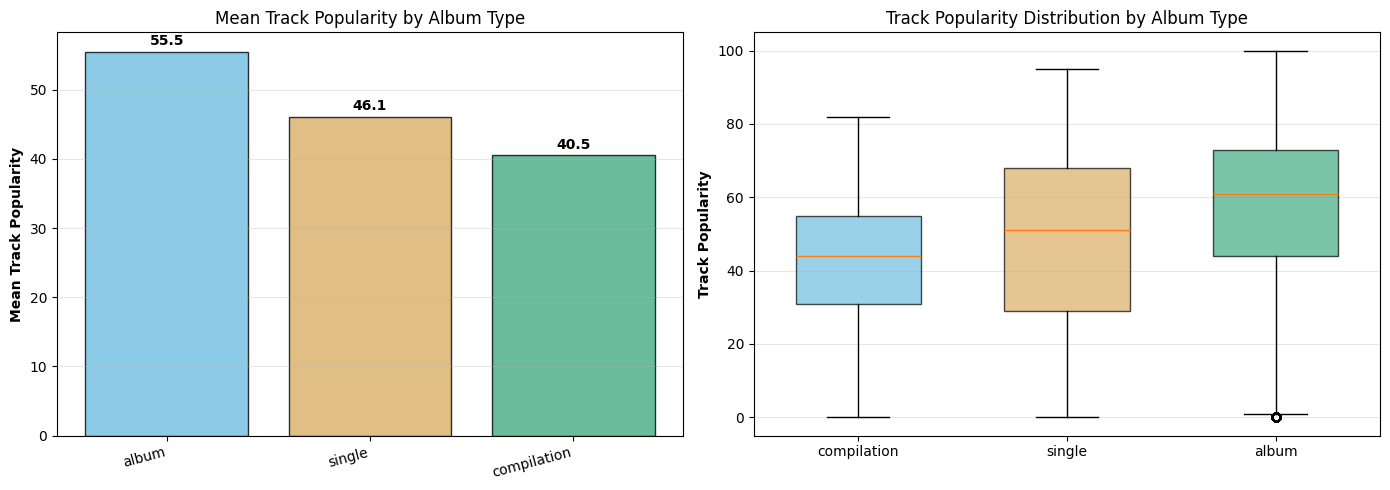

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

q1_mean_pop = q1_stats['track_popularity_mean'].sort_values(ascending=False)
colors_q1 = ['#6FBEE0', '#DAAF65', '#42AB84']

axes[0].bar(range(len(q1_mean_pop)), q1_mean_pop.values, 
            color=colors_q1, alpha=0.8, edgecolor='black')
axes[0].set_xticks(range(len(q1_mean_pop)))
axes[0].set_xticklabels(q1_mean_pop.index, rotation=15, ha='right')
axes[0].set_ylabel('Mean Track Popularity', fontweight='bold')
axes[0].set_title('Mean Track Popularity by Album Type')
axes[0].grid(axis='y', alpha=0.3)

for i, val in enumerate(q1_mean_pop.values):
    axes[0].text(i, val + 1, f'{val:.1f}', ha='center', fontweight='bold')

q1_album_data = df['album_type'].unique()
box_data = [df[df['album_type'] == atype]['track_popularity'] for atype in q1_album_data]
bp = axes[1].boxplot(box_data, labels=q1_album_data, patch_artist=True, widths=0.6)

for patch, color in zip(bp['boxes'], colors_q1):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_ylabel('Track Popularity', fontweight='bold')
axes[1].set_title('Track Popularity Distribution by Album Type')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


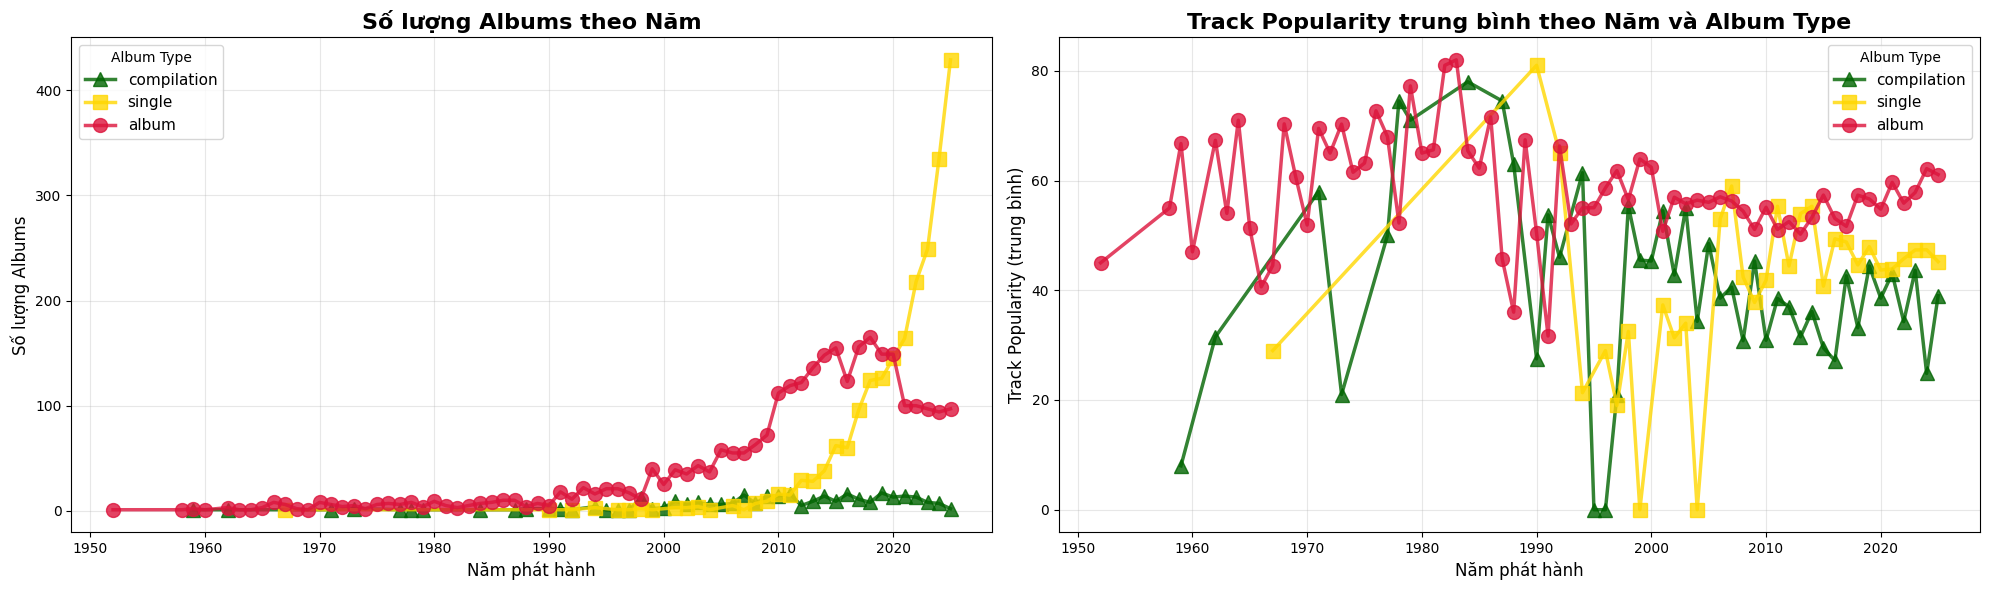

In [10]:
# Số lượng Albums duy nhất theo Năm
df['release_year'] = pd.to_datetime(df['album_release_date'], format='mixed', errors='coerce').dt.year
df_unique_albums = df.drop_duplicates(subset=['album_id'])
yearly_album_count = df_unique_albums.groupby(['release_year', 'album_type']).size().reset_index(name='album_count')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
# 1: Số lượng Albums duy nhất theo Năm 
colors_line = {'album': '#DC143C', 'single': '#FFD700', 'compilation': '#006400'}
markers = {'album': 'o', 'single': 's', 'compilation': '^'}
for album_type in df['album_type'].unique():
    data = yearly_album_count[yearly_album_count['album_type'] == album_type]
    ax1.plot(data['release_year'], data['album_count'], marker=markers.get(album_type, 'o'), label=album_type, linewidth=2.5, markersize=10, color=colors_line.get(album_type, 'gray'), alpha=0.8)

ax1.set_title('Số lượng Albums theo Năm', fontsize=16, fontweight='bold')
ax1.set_xlabel('Năm phát hành', fontsize=12)
ax1.set_ylabel('Số lượng Albums', fontsize=12)
ax1.legend(title='Album Type', fontsize=11, loc='best')
ax1.grid(True, alpha=0.3)

# 2: Track Popularity trung bình theo Năm và Album Type
yearly_popularity = df.groupby(['release_year', 'album_type'])['track_popularity'].mean().reset_index(name='avg_popularity')
for album_type in df['album_type'].unique():
    data = yearly_popularity[yearly_popularity['album_type'] == album_type]
    ax2.plot(data['release_year'], data['avg_popularity'], marker=markers.get(album_type, 'o'), label=album_type, linewidth=2.5, markersize=10, color=colors_line.get(album_type, 'gray'), alpha=0.8)
ax2.set_title('Track Popularity trung bình theo Năm và Album Type', fontsize=16, fontweight='bold')
ax2.set_xlabel('Năm phát hành', fontsize=12)
ax2.set_ylabel('Track Popularity (trung bình)', fontsize=12)
ax2.legend(title='Album Type', fontsize=11, loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**H0:** Không có sự khác biệt có ý nghĩa thống kê về độ phổ biến trung bình của bài hát giữa các loại album (Album, Single, Compilation).

$$H_0: \mu_{album} = \mu_{single} = \mu_{compilation}$$

**H1:** Có ít nhất một loại album có độ phổ biến trung bình khác biệt có ý nghĩa so với các loại còn lại.

$$H_1: \exists \, i \neq j : \mu_i \neq \mu_j$$

In [11]:
group_album = df[df['album_type'] == 'album']['track_popularity'].dropna()
group_single = df[df['album_type'] == 'single']['track_popularity'].dropna()
group_compilation = df[df['album_type'] == 'compilation']['track_popularity'].dropna()

data_groups = [group_album, group_single, group_compilation]
labels = ['Album', 'Single', 'Compilation']

print("Các Kiểm Định Thống Kê:\n")

# 1. ANOVA
f_stat, p_value_anova = f_oneway(group_album, group_single, group_compilation)
print("1. ANOVA (Một Chiều):")
print(f"   Giá trị F: {f_stat:.4f}")
print(f"   Giá trị P: {p_value_anova:.4e}")

if p_value_anova < 0.05:
    print(f"   Kết quả: Có sự khác biệt có ý nghĩa (p < 0.05)")
    means = [g.mean() for g in data_groups]
    max_idx = np.argmax(means)
    print(f"   Trung bình cao nhất: {labels[max_idx]} ({means[max_idx]:.2f})")

Các Kiểm Định Thống Kê:

1. ANOVA (Một Chiều):
   Giá trị F: 198.3060
   Giá trị P: 5.8560e-85
   Kết quả: Có sự khác biệt có ý nghĩa (p < 0.05)
   Trung bình cao nhất: Album (55.53)


**H0** Các phân phối độ phổ biến của bài hát giữa ba loại album (Album, Single, Compilation) là giống nhau.

$$H_0: F_{album}(x) = F_{single}(x) = F_{compilation}(x)$$

**H1** Có ít nhất một loại album có phân phối độ phổ biến khác biệt với các loại còn lại.

$$H_1: \exists \, i \neq j : F_i(x) \neq F_j(x)$$

In [12]:
# 2. Kruskal-Wallis
h_stat, p_value_kruskal = kruskal(group_album, group_single, group_compilation)
print(f"\n2. Kruskal-Wallis:")
print(f"   Giá trị H: {h_stat:.4f}")
print(f"   Giá trị P: {p_value_kruskal:.4e}")
print(f"   Kết quả: {'Có sự khác biệt có ý nghĩa' if p_value_kruskal < 0.05 else 'Không có sự khác biệt có ý nghĩa'}")


2. Kruskal-Wallis:
   Giá trị H: 418.0297
   Giá trị P: 1.6827e-91
   Kết quả: Có sự khác biệt có ý nghĩa


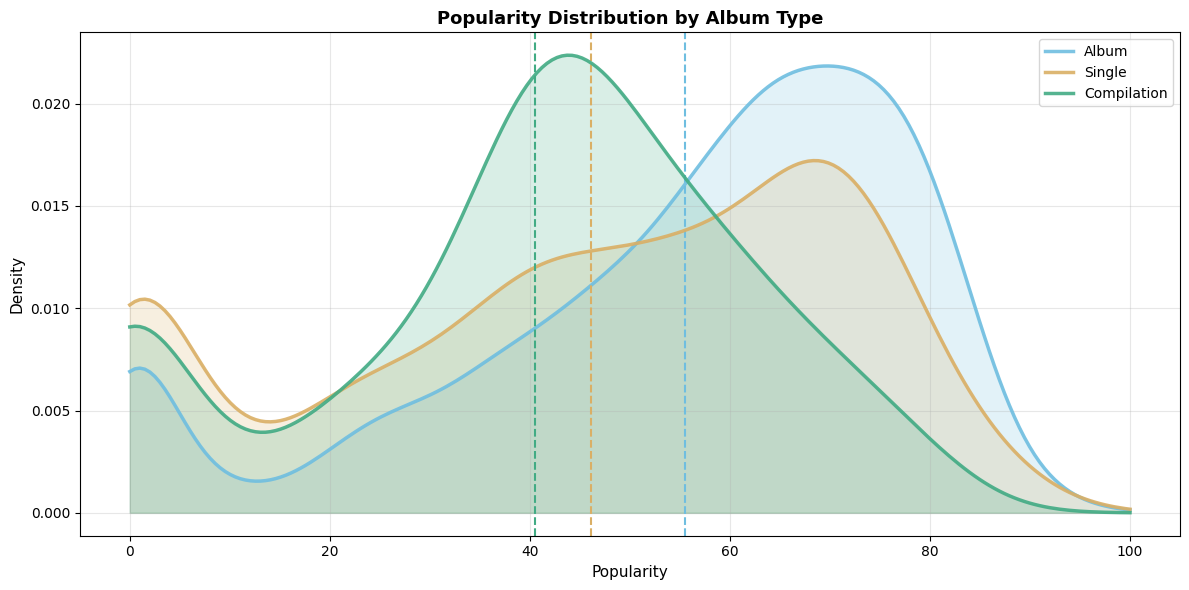

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#6FBEE0', '#DAAF65', '#42AB84']
x_range = np.linspace(0, 100, 200)

for data, label, color in zip(data_groups, labels, colors):
    kde = gaussian_kde(data)
    ax.plot(x_range, kde(x_range), color=color, linewidth=2.5, label=label, alpha=0.9)
    ax.fill_between(x_range, kde(x_range), alpha=0.2, color=color)
    ax.axvline(data.mean(), color=color, linestyle='--', linewidth=1.5)

ax.set_title('Popularity Distribution by Album Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Popularity', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### C. Kết quả & Giải thích

**Câu trả lời:** Album có độ phổ biến cao nhất với độ phổ biến trung bình 55.5, trong khi đĩa đơn ở mức 46.1 và tuyển tập thấp nhất 40.5.

**Phát hiện chính:**

 - Album đầy đủ vượt trội hơn đĩa đơn và tuyển tập

 - Tuyển tập có độ phổ biến thấp nhất mặc dù thường tập hợp các bài hát "hay nhất" - có thể do sở thích của người nghe đối với trải nghiệm album gắn kết hay do tuyển tập bị coi là phát hành lại không có nội dung mới.

 - Số lượng Single phát hành tăng nhanh, nhưng độ phổ biến trung bình lại thấp hơn. Điều này cho thấy thị trường đang bị "loãng" bởi rất nhiều Single thất bại (có thể từ các nghệ sĩ mới), kéo độ phổ biến trung bình xuống thấp. Vì vậy, Album vẫn là lựa chọn an toàn và ổn định hơn để duy trì độ nổi tiếng cao.

- Kết quả kiểm định ANOVA và Kruskal-Wallis đều cho p-value (nhỏ hơn so với 0.05). Điều này khẳng định sự chênh lệch về độ phổ biến giữa Album, Single và Compilation là **thực tế và có ý nghĩa thống kê**, chứ không phải ngẫu nhiên.

**Ý nghĩa thực tiễn:**

 - Nghệ sĩ nên cân nhắc phát hành album đầy đủ thay vì chỉ đĩa đơn khi có đủ tài liệu - dữ liệu cho thấy album đầy đủ đạt độ phổ biến cao hơn mặc dù yêu cầu cam kết nghe lâu hơn. Các hãng thu âm đầu tư vào sản xuất album có thể mong đợi lợi nhuận về độ phổ biến tốt hơn so với chiến lược chỉ phát hành đĩa đơn.

 - Tuy nhiên, cần lưu ý rằng đĩa đơn có số lượng cao hơn (2,248 bài) so với album trong những năm gần đây - xu hướng phát hành đĩa đơn có thể do cân nhắc chi phí và kinh tế phát trực tuyến, không chỉ tiềm năng độ phổ biến.

**Hạn chế:**

 - Phân tích không tính đến ngân sách quảng bá - album thường có chi phí tiếp thị lớn hơn so với đĩa đơn. Cũng không phân biệt album đầu tay so với album của nghệ sĩ đã thành danh. Tập dữ liệu có thể thiên vị về các album thành công (thiên kiến sống sót).

---

## 4.5 Câu hỏi 2: Explicit content và popularity

### Question

Những bài hát có explicit content (`explicit` = True) có độ phổ biến cao hơn hay thấp hơn so với những bài không explicit?

### A. Tiền xử lý

Kiểm tra phân bố các bài hát có nội dung nhạy cảm so với không nhạy cảm và tính thống kê để so sánh.

1. **Kiểm tra phân bố**: Xác định tỷ lệ nhạy cảm so với không nhạy cảm trong tập dữ liệu
2. **Tính thống kê**: Tính trung bình, trung vị, độ lệch chuẩn của track_popularity cho cả 2 nhóm
3. **Chuẩn bị dữ liệu so sánh**: Tạo tập dữ liệu cho kiểm định thống kê và trực quan hóa

In [14]:
q2_explicit_dist = df['explicit'].value_counts()
print('Distribution:')
print(q2_explicit_dist)
print(f'\nExplicit: {q2_explicit_dist[True] / len(df) * 100:.2f}%')
print(f'Non-Explicit: {q2_explicit_dist[False] / len(df) * 100:.2f}%')

Distribution:
explicit
False    6582
True     2190
Name: count, dtype: int64

Explicit: 24.97%
Non-Explicit: 75.03%


In [15]:
q2_stats = df.groupby('explicit').agg({
    'track_popularity': ['mean', 'median', 'std', 'count'],
    'artist_popularity': ['mean', 'median']
}).round(2)

q2_stats.columns = ['_'.join(col) for col in q2_stats.columns]
q2_stats


,track_popularity_mean,track_popularity_median,track_popularity_std,track_popularity_count,artist_popularity_mean,artist_popularity_median
explicit,,,,,,
False,50.48,55.0,24.27,6582,68.03,72.0
True,57.53,64.0,22.64,2190,75.82,81.0


### B. Phân tích

**Phương pháp phân tích:**

So sánh độ phổ biến bài hát giữa nội dung nhạy cảm và không nhạy cảm để xác định loại nội dung nào có độ phổ biến cao hơn:

1. **So sánh theo nhóm**: So sánh trung bình và trung vị track_popularity giữa nhạy cảm và không nhạy cảm
2. **Trực quan hóa phân bố**: Biểu đồ hộp và biểu đồ tần suất để so sánh toàn bộ phân bố
3. **Kiểm định thống kê:** Chứng minh giả định bằng thống kê

**Kết quả mong đợi:**
- Biểu đồ cột: So sánh độ phổ biến trung bình
- Biểu đồ hộp: So sánh phân bố
- Biểu đồ đường: Mức độ phổ biến theo từng năm

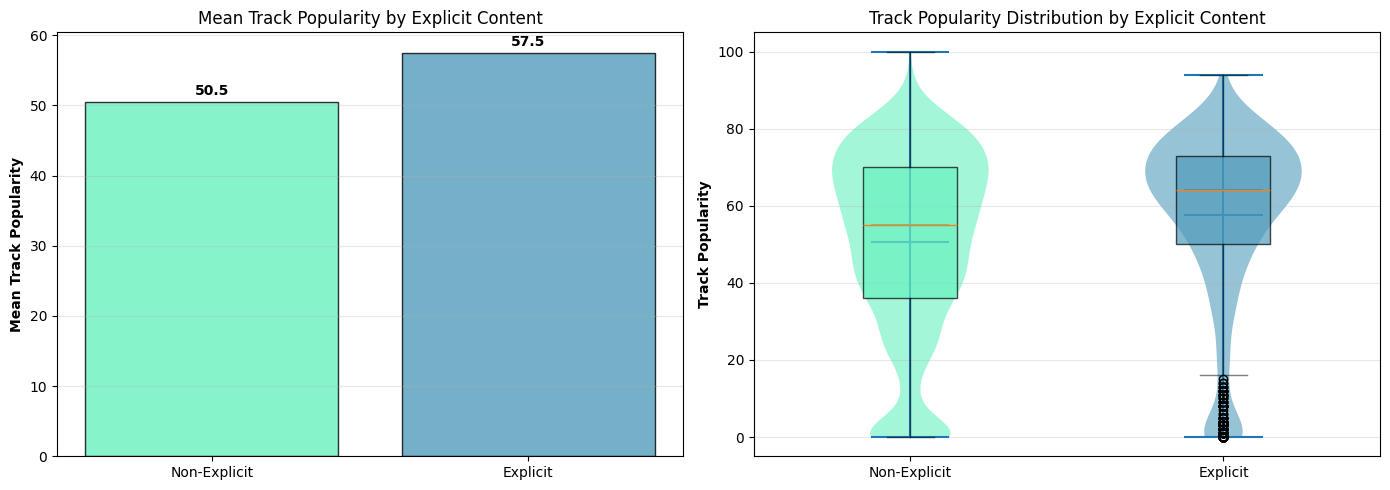

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

q2_explicit = df[df['explicit'] == True]['track_popularity']
q2_non_explicit = df[df['explicit'] == False]['track_popularity']

# Subplot 1: Bar chart of mean popularity
q2_means = pd.Series({
    'Non-Explicit': q2_non_explicit.mean(),
    'Explicit': q2_explicit.mean()
})
colors_q2 = ['#68F1BF', '#519CBA']

axes[0].bar(range(len(q2_means)), q2_means.values, 
            color=colors_q2, alpha=0.8, edgecolor='black')
axes[0].set_xticks(range(len(q2_means)))
axes[0].set_xticklabels(q2_means.index, rotation=0)
axes[0].set_ylabel('Mean Track Popularity', fontweight='bold')
axes[0].set_title('Mean Track Popularity by Explicit Content')
axes[0].grid(axis='y', alpha=0.3)

for i, val in enumerate(q2_means.values):
    axes[0].text(i, val + 1, f'{val:.1f}', ha='center', fontweight='bold')

# Subplot 2: Violin plot with boxplot inside
q2_data = [q2_non_explicit, q2_explicit]
parts = axes[1].violinplot(q2_data, positions=[0, 1], showmeans=True, showmedians=True)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors_q2[i])
    pc.set_alpha(0.6)

# Add boxplot inside
bp = axes[1].boxplot(q2_data, positions=[0, 1], widths=0.3, patch_artist=True,
                      boxprops=dict(alpha=0.7),
                      whiskerprops=dict(alpha=0.5),
                      capprops=dict(alpha=0.5))

for patch, color in zip(bp['boxes'], colors_q2):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Non-Explicit', 'Explicit'])
axes[1].set_ylabel('Track Popularity', fontweight='bold')
axes[1].set_title('Track Popularity Distribution by Explicit Content')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

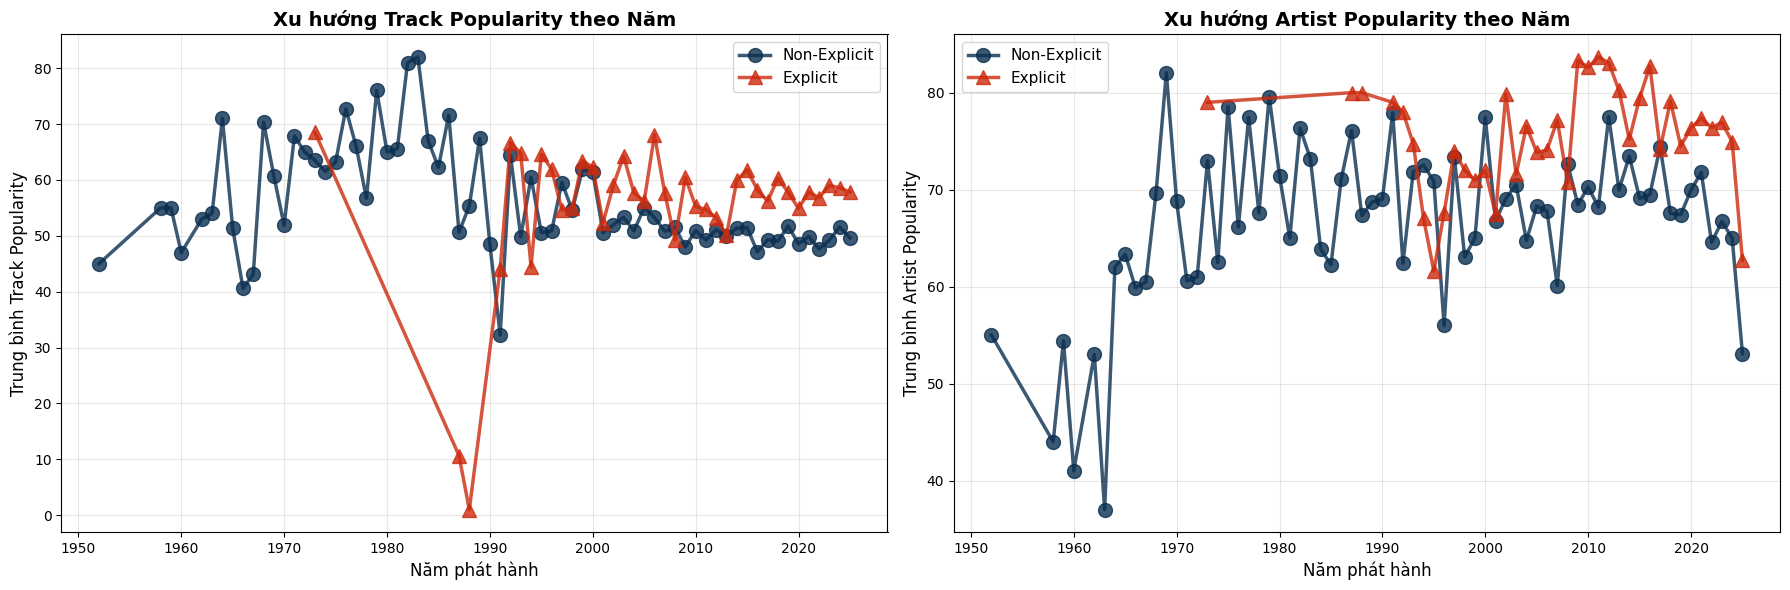

In [17]:
# Xu hướng Popularity theo năm
df['release_year'] = pd.to_datetime(df['album_release_date'], format='mixed', errors='coerce').dt.year
# Tính theo năm
yearly_track_pop = df.groupby(['release_year', 'explicit'])['track_popularity'].mean().reset_index()
yearly_artist_pop = df.groupby(['release_year', 'explicit'])['artist_popularity'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
colors_line = {False: "#0B2F50", True: "#CC2A0D"}
markers = {False: 'o', True: '^'}
# 1. Line Chart - Track Popularity theo Năm
for explicit_val in [False, True]:
    data = yearly_track_pop[yearly_track_pop['explicit'] == explicit_val]
    label = 'Explicit' if explicit_val else 'Non-Explicit'
    axes[0].plot(data['release_year'], data['track_popularity'],  marker=markers[explicit_val], label=label, linewidth=2.5, markersize=10, color=colors_line[explicit_val], alpha=0.8)

axes[0].set_title('Xu hướng Track Popularity theo Năm', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Năm phát hành', fontsize=12)
axes[0].set_ylabel('Trung bình Track Popularity', fontsize=12)
axes[0].legend(fontsize=11, loc='best')
axes[0].grid(True, alpha=0.3)
# 2. Line Chart - Artist Popularity theo Năm
for explicit_val in [False, True]:
    data = yearly_artist_pop[yearly_artist_pop['explicit'] == explicit_val]
    label = 'Explicit' if explicit_val else 'Non-Explicit'
    axes[1].plot(data['release_year'], data['artist_popularity'],  marker=markers[explicit_val], label=label, linewidth=2.5, markersize=10, color=colors_line[explicit_val], alpha=0.8)

axes[1].set_title('Xu hướng Artist Popularity theo Năm', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Năm phát hành', fontsize=12)
axes[1].set_ylabel('Trung bình Artist Popularity', fontsize=12)
axes[1].legend(fontsize=11, loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Kiểm định 1 phía: Explicit > Non-Explicit**

- **H0**: Độ phổ biến *Explicit* ≤ Độ phổ biến *Non-Explicit*
- **H1**: Độ phổ biến *Explicit* > Độ phổ biến *Non-Explicit*


In [18]:
# Các Kiểm Định Thống Kê
from scipy.stats import ttest_ind, mannwhitneyu
import numpy as np

# 1. Kiểm Định T
t_stat, p_value_ttest = ttest_ind(q2_explicit, q2_non_explicit, alternative='greater')
print("1. Kiểm định T:")
print(f"Giá trị T: {t_stat:.4f}")
print(f"Giá trị P: {p_value_ttest:.4e}")
print(f"Kết quả: {'Bác bỏ H0' if p_value_ttest < 0.05 else 'Chấp nhận H0'} (p < 0.05)")

# 2. Kiểm Định Mann-Whitney U
u_stat, p_value_mann = mannwhitneyu(q2_explicit, q2_non_explicit, alternative='greater')
print("\n2. Kiểm định Mann-Whitney U:")
print(f"Giá trị U: {u_stat:.4f}")
print(f"Giá trị P: {p_value_mann:.4e}")
print(f"Kết quả: {'Bác bỏ H0' if p_value_mann < 0.05 else 'Chấp nhận H0'} (p < 0.05)")

1. Kiểm định T:
Giá trị T: 11.9734
Giá trị P: 4.4089e-33
Kết quả: Bác bỏ H0 (p < 0.05)

2. Kiểm định Mann-Whitney U:
Giá trị U: 8568838.0000
Giá trị P: 1.8213e-40
Kết quả: Bác bỏ H0 (p < 0.05)


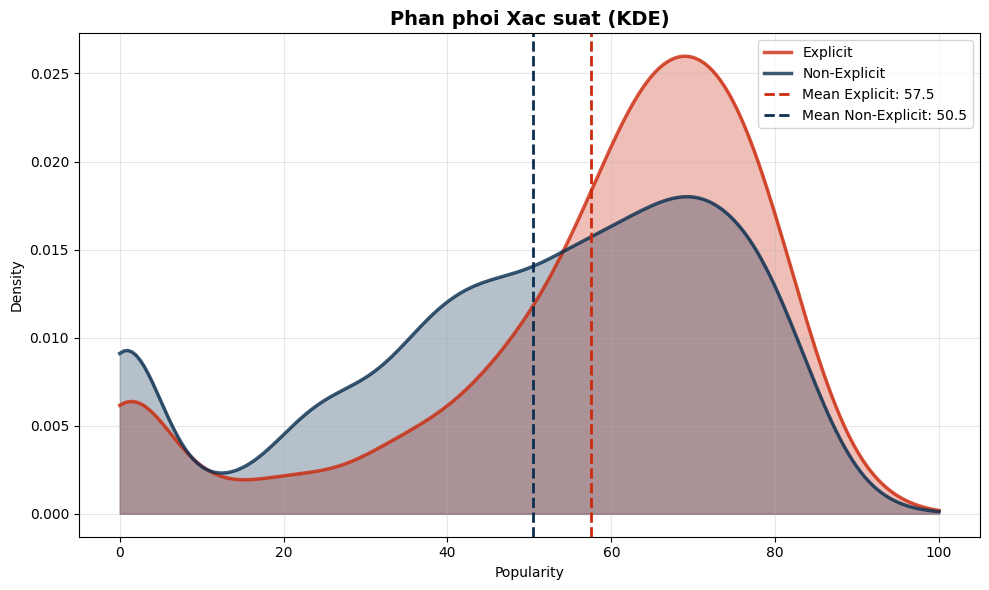

In [19]:
kde_explicit = gaussian_kde(q2_explicit.dropna())
kde_non_explicit = gaussian_kde(q2_non_explicit.dropna())
x_range = np.linspace(0, 100, 200)

plt.figure(figsize=(10, 6))
plt.plot(x_range, kde_explicit(x_range), color='#CC2A0D', linewidth=2.5, label='Explicit', alpha=0.8)
plt.fill_between(x_range, kde_explicit(x_range), alpha=0.3, color='#CC2A0D')
plt.plot(x_range, kde_non_explicit(x_range), color='#0B2F50', linewidth=2.5, label='Non-Explicit', alpha=0.8)
plt.fill_between(x_range, kde_non_explicit(x_range), alpha=0.3, color='#0B2F50')
plt.axvline(q2_explicit.mean(), color='#CC2A0D', linestyle='--', linewidth=2, label=f'Mean Explicit: {q2_explicit.mean():.1f}')
plt.axvline(q2_non_explicit.mean(), color='#0B2F50', linestyle='--', linewidth=2, label=f'Mean Non-Explicit: {q2_non_explicit.mean():.1f}')
plt.title('Phan phoi Xac suat (KDE)', fontsize=14, fontweight='bold')
plt.xlabel('Popularity')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### C. Kết quả & Giải thích

**Câu trả lời:** Các bài hát có nội dung nhạy cảm có độ phổ biến cao hơn đáng kể so với các bài hát không nhạy cảm.

**Phát hiện chính:**

Nội dung nhạy cảm đạt độ phổ biến trung bình 57.5 so với không nhạy cảm 50.5 - chênh lệch 7 điểm. 

Trung vị cũng cho thấy mô hình tương tự: nhạy cảm (64) vượt không nhạy cảm (55) 9 điểm. Biểu đồ hộp cho thấy các bài hát nhạy cảm có phân bố tập trung ở phạm vi cao hơn với Q3=73 so với Q3=70 của không nhạy cảm.

Độ nổi tiếng của bài hát và nghệ sĩ cũng cao hơn đối với nội dung nhạy cảm (75.8 so với 68.0), cho thấy rằng các nghệ sĩ nổi tiếng hơn và có thể tự do hơn để phát hành những bài hát có chứa nội dung nhạy cảm mà vẫn duy trì được mức độ phổ biến.

**Ý nghĩa thực tiễn:**

Dữ liệu cho thấy nội dung nhạy cảm không làm giảm độ phổ biến như nhiều người lo ngại - trái lại còn liên kết với độ phổ biến cao hơn. Điều này có thể do các nghệ sĩ đã thành danh (đã có lượng người hâm mộ) thoải mái hơn với lời bài hát nhạy cảm, hoặc do nội dung nhạy cảm cộng hưởng nhiều hơn với nhân khẩu học phát trực tuyến cốt lõi (khán giả trẻ hơn).

Nghệ sĩ không cần tự kiểm duyệt để theo đuổi độ phổ biến - biểu đạt chân thực qua lời bài hát nhạy cảm không bị phạt về mặt thành công thương mại. Các hãng thu âm và nền tảng cũng nên đánh giá lại những lo ngại về việc nội dung nhạy cảm hạn chế phạm vi tiếp cận.

**Hạn chế:**

Tương quan không có nghĩa là nhân quả - nội dung nhạy cảm không trực tiếp gây ra độ phổ biến cao hơn. Có thể có các yếu tố gây nhiễu như thể loại (hip-hop thường nhạy cảm và phổ biến), vị thế nghệ sĩ, hoặc nhân khẩu học mục tiêu. Phân tích không kiểm soát các biến này.